In [ ]:
# Install hypertools (run this first on Colab)
%pip install -q "hypertools[interactive]"

# Dimensionality reduction

The `reduce` function reduces the dimensionality of an array or list of arrays. The default model is IncrementalPCA, but a variety of models are supported. Note that `ndims` defaults to `None`, which means no dimensionality reduction is performed unless you explicitly request a target number of dimensions via `ndims`.

Supported models include: PCA, IncrementalPCA, SparsePCA, MiniBatchSparsePCA, KernelPCA, FastICA, FactorAnalysis, TruncatedSVD, DictionaryLearning, MiniBatchDictionaryLearning, TSNE, Isomap, SpectralEmbedding, LocallyLinearEmbedding, MDS, UMAP, and six torch autoencoders (Autoencoder, DeepAutoencoder, SparseAutoencoder, ConvolutionalAutoencoder, SequenceAutoencoder, VariationalAutoencoder).

## Import Hypertools

In [1]:
import hypertools as hyp
import matplotlib.pyplot as plt

%matplotlib inline

## Load your data

First, we'll load one of the sample datasets. This dataset is a list of 2 `numpy` arrays, each containing average brain activity (fMRI) from 18 subjects listening to the same story, fit using Hierarchical Topographic Factor Analysis (HTFA) with 100 nodes.  The rows are timepoints and the columns are fMRI components.

See the [full dataset](http://dataspace.princeton.edu/jspui/handle/88435/dsp015d86p269k) or the [HTFA article](https://www.biorxiv.org/content/early/2017/02/07/106690) for more info on the data and HTFA, respectively.

In [2]:
weights = hyp.load('weights_avg')

## Reduce one array

Let's look at one array from the dataset above.

In [3]:
print('Array shape: (%d, %d)' % weights[0].shape)

Array shape: (100, 100)


To reduce this array, pass the array to `hyp.reduce` along with the desired number of dimensions via `ndims`. Below we reduce from 100 features to 3 features by setting `ndims=3` (if `ndims` is omitted, no reduction is performed).

In [4]:
reduced_array = hyp.reduce(weights[0], ndims=3)
print('Reduced array shape: (%d, %d)' % reduced_array.shape)

Reduced array shape: (100, 3)


## Reduce list of arrays

A list or numpy array of multiple arrays can also be reduced into a common space. That is, the data can be combined, reduced as a whole, then split back into individual elements and outputted via `hyp.reduce`.

Here we show this with the two arrays in the weights dataset. The first was printed above as a 100 x 100 array (timepoints by components); the second has the same shape.

In [5]:
reduced_arrays = hyp.reduce(weights, ndims=3)
print('Shape of first reduced array: ', reduced_arrays[0].shape)
print('Shape of second reduced array: ', reduced_arrays[1].shape)

Shape of first reduced array:  (100, 3)
Shape of second reduced array:  (100, 3)


We can see that each array has been reduced from 100 features to 3 features (since we set `ndims=3`), with the number of datapoints unchanged. Reduced data can be drawn directly with `hyp.plot(..., reduce=None)`: the coordinates are already three-dimensional, so nothing further is reduced.

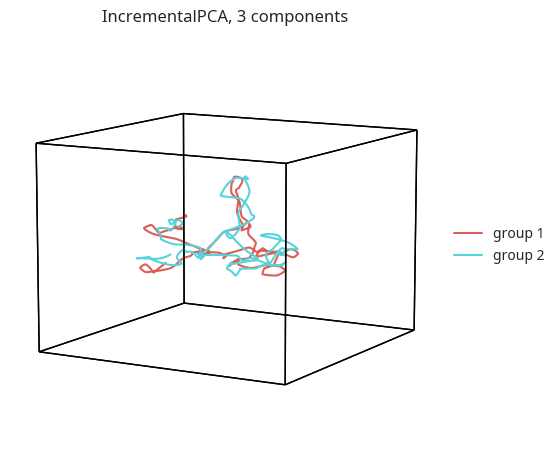

In [6]:
fig = hyp.plot(reduced_arrays, reduce=None, names=['group 1', 'group 2'], title='IncrementalPCA, 3 components')

## Reduce to a specified number of dimensions

You may prefer to reduce to a specific number of features other than three. To achieve this, simply pass the number of desired features (as an int) to the `ndims` argument, as below.

In [7]:
reduced_4 = hyp.reduce(weights, ndims=4)
print('Shape of first reduced array: ', reduced_4[0].shape)
print('Shape of second reduced array: ', reduced_4[1].shape)

Shape of first reduced array:  (100, 4)
Shape of second reduced array:  (100, 4)


## Reduce list of arrays with specific parameters

For finer control of parameters, pass the `reduce` argument a dictionary with the keys `model` (the desired reduction method) and `kwargs` (a dictionary of model parameters). See [scikit-learn](http://scikit-learn.org/stable/index.html) model docs for details on parameters supported for each model.

Below, `whiten=True` rescales each component to unit variance, so the returned features have equal spread rather than the first principal component dominating the range. The shape of the data is preserved; the relative scale of the components is not.

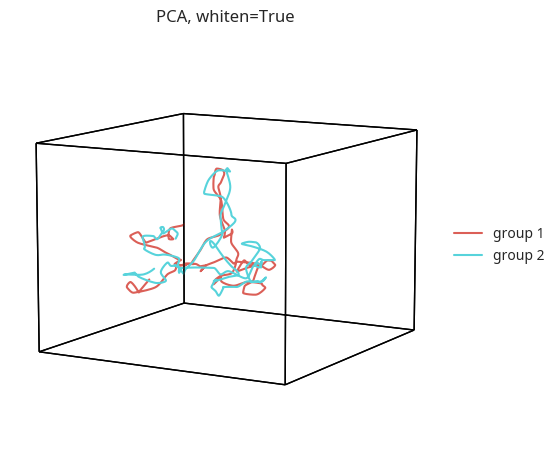

In [8]:
reduced_params = hyp.reduce(weights, reduce={'model': 'PCA', 'kwargs': {'whiten': True}}, ndims=3)
fig = hyp.plot(reduced_params, reduce=None, names=['group 1', 'group 2'], title='PCA, whiten=True')

## Nonlinear methods: TSNE and UMAP

You can also opt to use different reduction methods. TSNE and UMAP are nonlinear neighbor embeddings: they preserve each point's local neighborhood rather than the directions of greatest variance, so distances between far-apart points in the embedding are not meaningful. TSNE provides no reusable projection (scikit-learn's `TSNE` has no `transform` method), so a new dataset cannot be mapped into an existing TSNE embedding; UMAP does. Both depend on their random initialization, so we fix `random_state` for a reproducible figure. Below we reduce both arrays at once with each method and draw the two embeddings side by side into axes we supply with `ax=`.

TSNE: (100, 3)  UMAP: (100, 3)


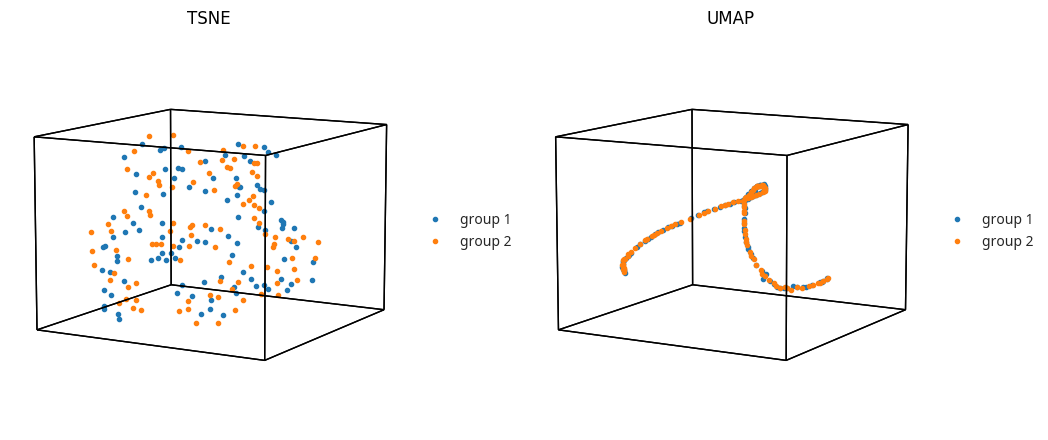

In [9]:
reduced_TSNE = hyp.reduce(weights, reduce={'model': 'TSNE', 'kwargs': {'random_state': 0}}, ndims=3)
reduced_UMAP = hyp.reduce(weights, reduce={'model': 'UMAP', 'kwargs': {'random_state': 0, 'n_jobs': 1}}, ndims=3)
print('TSNE:', reduced_TSNE[0].shape, ' UMAP:', reduced_UMAP[0].shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), subplot_kw={'projection': '3d'})
hyp.plot(reduced_TSNE, '.', reduce=None, ax=axes[0], names=['group 1', 'group 2'], title='TSNE', show=False)
hyp.plot(reduced_UMAP, '.', reduce=None, ax=axes[1], names=['group 1', 'group 2'], title='UMAP', show=False)
fig.tight_layout()

## Autoencoders

`reduce` also accepts torch autoencoders (`'Autoencoder'`, `'DeepAutoencoder'`, `'SparseAutoencoder'`, `'ConvolutionalAutoencoder'`, `'SequenceAutoencoder'`, `'VariationalAutoencoder'`; the `[torch]` extra installs itself on first use). They are trained networks, so the model kwargs are training settings: `epochs`, `batch_size`, `random_state`. A shallow `Autoencoder` with a small budget is enough for these two 100 x 100 arrays; the learned 3-D bottleneck plays the role of the principal components, but the encoder is nonlinear.

Autoencoder: (100, 3)


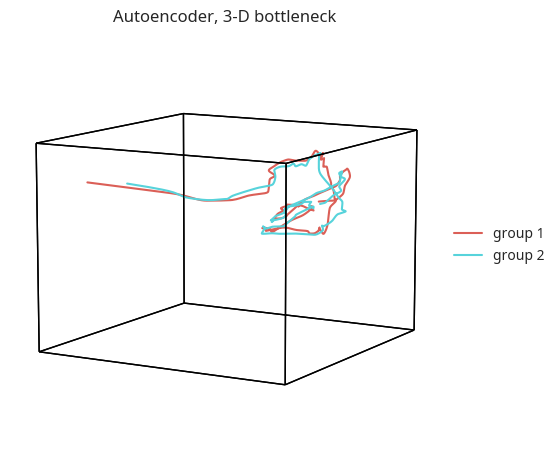

In [10]:
reduced_AE = hyp.reduce(weights, reduce={'model': 'Autoencoder',
                                         'kwargs': {'epochs': 40, 'batch_size': 20, 'random_state': 0}},
                        ndims=3)
print('Autoencoder:', reduced_AE[0].shape)
fig = hyp.plot(reduced_AE, reduce=None, names=['group 1', 'group 2'], title='Autoencoder, 3-D bottleneck')

## How many dimensions do you actually need?

`hyp.describe` is the companion to `hyp.reduce`: for each candidate number of dimensions it reduces the data and correlates the pairwise distances of the reduced data with those of the full data, so you can see how much structure each extra dimension buys. Called with the defaults it draws the curve; with `show=False` it returns only the dict of scores (`'average'` over the datasets, `'individual'` per dataset). For these data the curve starts around 0.8 at two dimensions, passes 0.9 by five, and keeps creeping toward 1 -- so three dimensions carry most of the pairwise-distance structure, and each further dimension buys a little less.

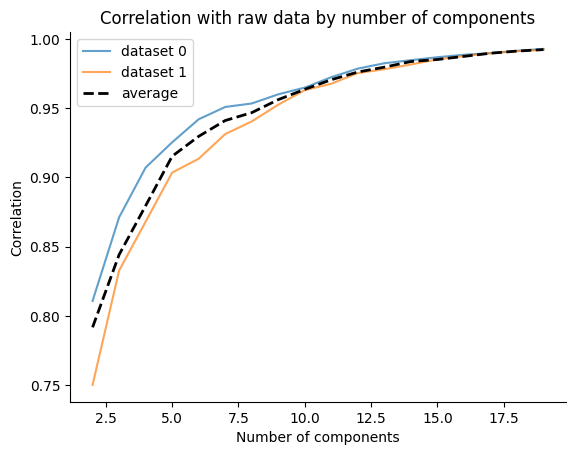

average correlation with the full data at 2..6 dimensions: [0.792, 0.844, 0.88, 0.915, 0.93]


In [11]:
scores = hyp.describe(weights, max_dims=20)
print('average correlation with the full data at 2..6 dimensions:',
      [round(float(v), 3) for v in scores['average'][:5]])

## Reusing a fitted reducer with `return_model`

`return_model=True` also returns the fitted reducer. Passing it back as `reduce=` applies the *same* projection to new data (via `.transform`) instead of refitting -- so two datasets reduced separately land in one shared coordinate system, exactly as if the model had seen both. Here we fit PCA on the first array only, then project the second through it, and compare against the joint fit from earlier.

fitted reducer: Reducer


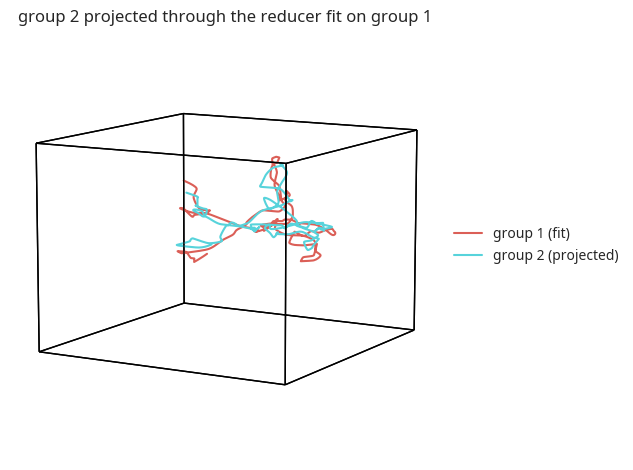

In [12]:
reduced_first, reducer = hyp.reduce(weights[0], ndims=3, return_model=True)
print('fitted reducer:', type(reducer).__name__)

reduced_second = hyp.reduce(weights[1], reduce=reducer)   # transform only, no refit
fig = hyp.plot([reduced_first, reduced_second], reduce=None, names=['group 1 (fit)', 'group 2 (projected)'],
               title='group 2 projected through the reducer fit on group 1')

## Next steps

- [`hyp.plot`](plot.ipynb) accepts the same `reduce=` / `ndims=` arguments and reduces before drawing.
- The `plot_autoencoders` and `plot_describe` gallery examples go deeper on the autoencoders and on `describe`.
- The [analyze tutorial](analyze.ipynb) chains reduction with normalization, alignment and clustering.